In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from lerobot.datasets.lerobot_dataset import LeRobotDataset

REPO_ID = "eternalmay33/01_02_black_merged"
CAMERAS = ["top", "left", "right", "gripper"]

dataset = LeRobotDataset(REPO_ID)
print(f"Dataset: {REPO_ID}")
print(f"Episodes: {dataset.meta.total_episodes}, Frames: {dataset.meta.total_frames}")
print(f"Features: {list(dataset.meta.features.keys())}")

# Load a sample frame
sample = dataset[0]
print(f"\nSample keys: {list(sample.keys())}")
for cam in CAMERAS:
    key = f"observation.images.{cam}"
    if key in sample:
        img = sample[key]
        print(f"  {cam}: {img.shape}, dtype={img.dtype}, range=[{img.min():.2f}, {img.max():.2f}]")

Dataset: eternalmay33/01_02_black_merged
Episodes: 144, Frames: 89932
Features: ['action', 'observation.state', 'observation.images.top', 'observation.images.left', 'observation.images.right', 'observation.images.gripper', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']

Sample keys: ['observation.images.top', 'observation.images.left', 'observation.images.right', 'observation.images.gripper', 'action', 'observation.state', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'task']
  top: torch.Size([3, 480, 640]), dtype=torch.float32, range=[0.05, 1.00]
  left: torch.Size([3, 480, 640]), dtype=torch.float32, range=[0.04, 1.00]
  right: torch.Size([3, 480, 640]), dtype=torch.float32, range=[0.06, 1.00]
  gripper: torch.Size([3, 480, 640]), dtype=torch.float32, range=[0.00, 0.64]


### Load SigLIP with attention output

SmolVLA uses `google/siglip-so400m-patch14-384`. The model splits each 384×384 input into a 27×27 grid of 14px patches = 729 patch tokens. Each transformer layer has self-attention — every patch attends to every other patch.

We hook `output_attentions=True` to get the raw attention weight matrices from all 27 layers.

In [22]:
from transformers import SiglipVisionModel, SiglipImageProcessor
from PIL import Image

SIGLIP_ID = "google/siglip-so400m-patch14-384"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# attn_implementation="eager" needed to extract attention weights
# (SDPA fuses softmax+matmul and doesn't store them)
vision_model = SiglipVisionModel.from_pretrained(
    SIGLIP_ID, attn_implementation="eager"
).to(device).eval()
processor = SiglipImageProcessor.from_pretrained(SIGLIP_ID)

print(f"SigLIP loaded on {device} (eager attention)")
print(f"  Patch size: {vision_model.config.patch_size}")
print(f"  Image size: {vision_model.config.image_size}")
print(f"  Num layers: {vision_model.config.num_hidden_layers}")
print(f"  Num heads: {vision_model.config.num_attention_heads}")
grid_size = vision_model.config.image_size // vision_model.config.patch_size
print(f"  Patch grid: {grid_size}x{grid_size} = {grid_size**2} tokens")

SigLIP loaded on cuda (eager attention)
  Patch size: 14
  Image size: 384
  Num layers: 27
  Num heads: 16
  Patch grid: 27x27 = 729 tokens


### Forward pass with attention extraction

Run a single image through SigLIP with `output_attentions=True`. This returns a tuple of attention tensors — one per layer, each shaped `(batch, num_heads, seq_len, seq_len)`.

In [23]:
def img_to_pil(img: torch.Tensor) -> Image.Image:
    """(C, H, W) float [0,1] -> PIL RGB"""
    return Image.fromarray((img.permute(1, 2, 0).clamp(0, 1).numpy() * 255).astype(np.uint8))


@torch.no_grad()
def get_attentions(img: torch.Tensor) -> list[torch.Tensor]:
    """Run SigLIP and return attention weights from all layers.
    
    Args:
        img: (C, H, W) float [0,1] tensor
    Returns:
        List of (num_heads, seq_len, seq_len) tensors, one per layer
    """
    pil = img_to_pil(img)
    inputs = processor(images=[pil], return_tensors="pt").to(device)
    outputs = vision_model(**inputs, output_attentions=True)
    # outputs.attentions: tuple of (1, num_heads, seq_len, seq_len) per layer
    attentions = [a[0].cpu() for a in outputs.attentions]  # drop batch dim
    return attentions


# Test on one image
test_img = sample["observation.images.top"]
attns = get_attentions(test_img)
print(f"Layers: {len(attns)}")
print(f"Shape per layer: {attns[0].shape}")
print(f"  → {attns[0].shape[0]} heads, {attns[0].shape[1]} tokens")

Layers: 27
Shape per layer: torch.Size([16, 729, 729])
  → 16 heads, 729 tokens


/tmp/ipykernel_59457/2795429225.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


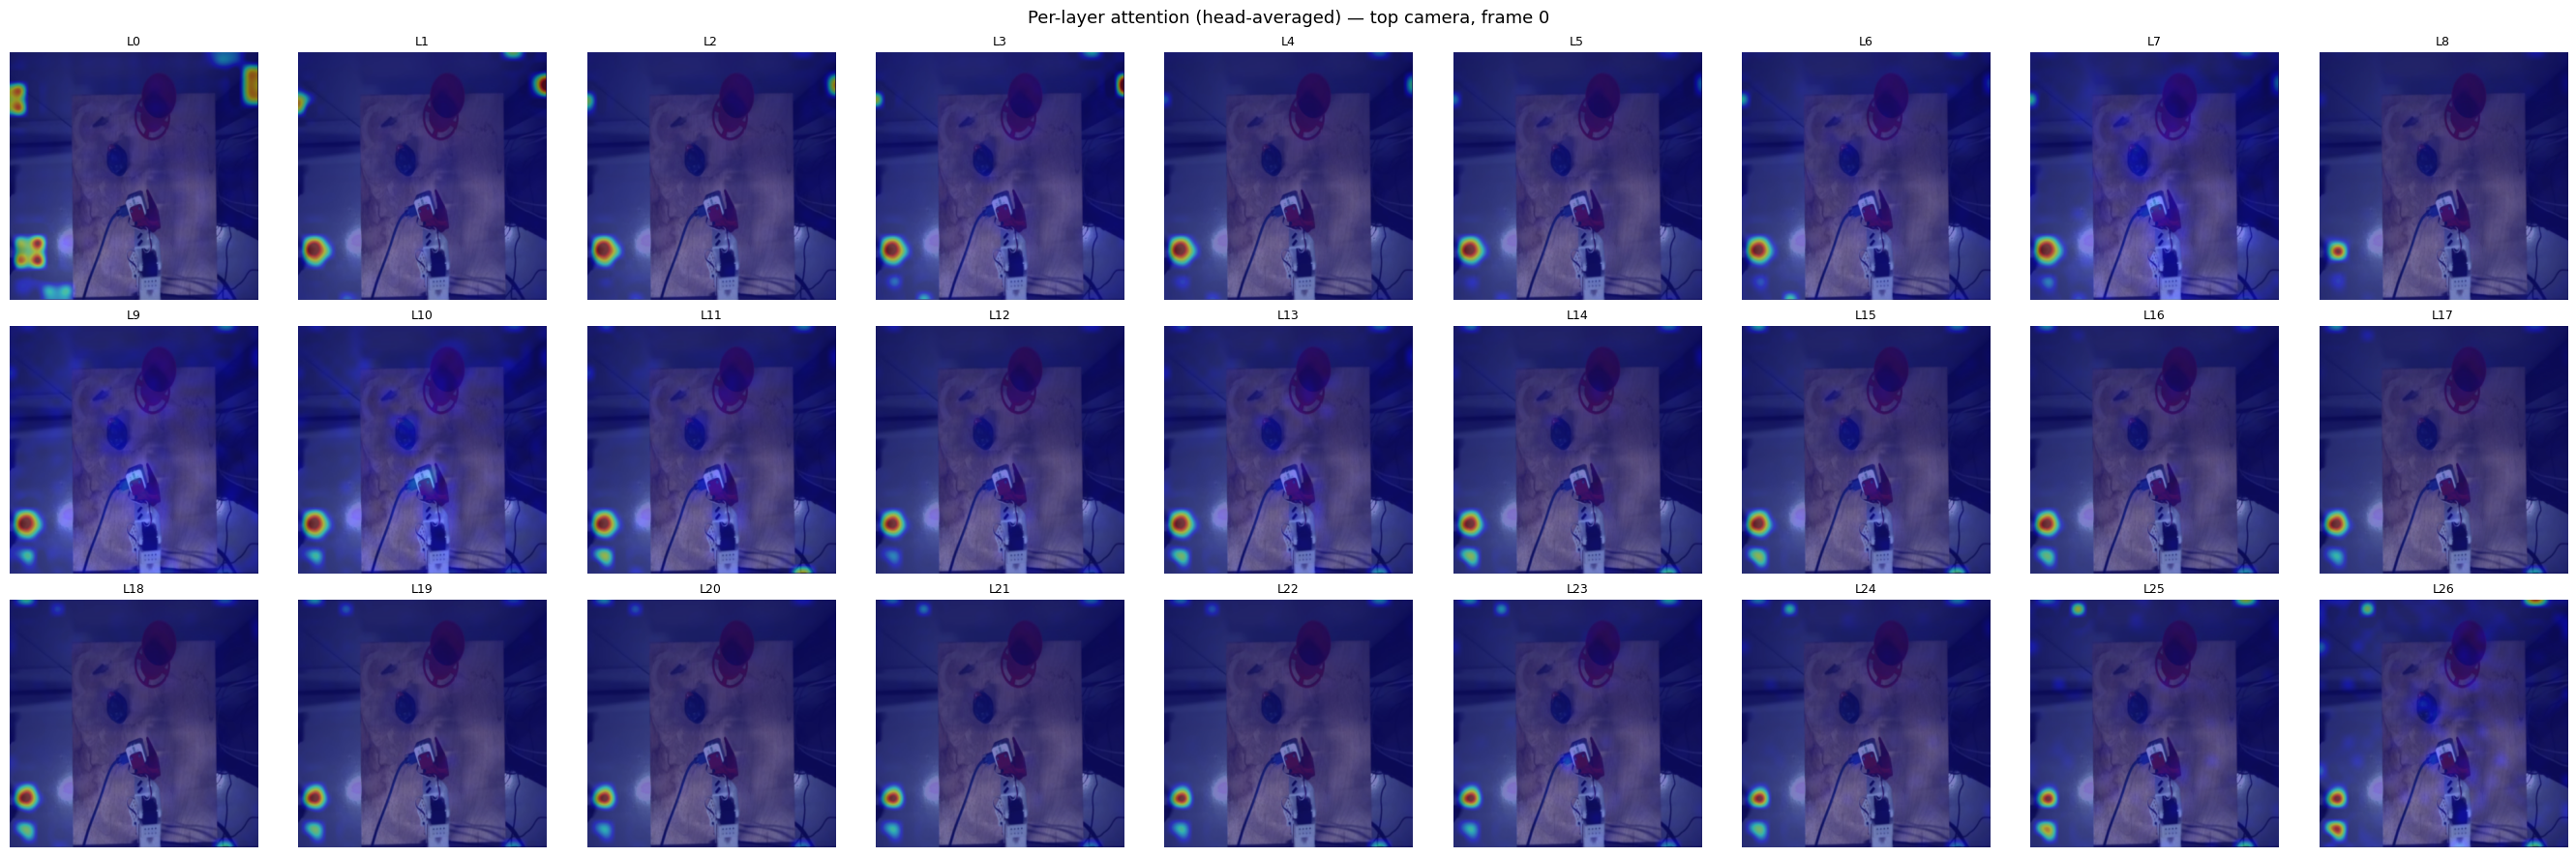

In [24]:
from scipy.ndimage import zoom

SIGLIP_SIZE = 384


def get_siglip_input(img: torch.Tensor) -> np.ndarray:
    """Get the 384x384 image that SigLIP actually sees."""
    pil = img_to_pil(img).resize((SIGLIP_SIZE, SIGLIP_SIZE), Image.BILINEAR)
    return np.array(pil)


def overlay_heatmap(img_384: np.ndarray, heatmap: np.ndarray,
                    alpha: float = 0.5, cmap_name: str = "jet") -> np.ndarray:
    H, W = img_384.shape[:2]
    gh, gw = heatmap.shape
    heatmap_full = zoom(heatmap, (H / gh, W / gw), order=3)
    heatmap_full = np.clip(heatmap_full, 0, 1)
    cmap = plt.cm.get_cmap(cmap_name)
    heatmap_colored = cmap(heatmap_full)[:, :, :3]
    img_float = img_384.astype(np.float32) / 255.0
    blended = (1 - alpha) * img_float + alpha * heatmap_colored
    return (blended * 255).astype(np.uint8)


def per_layer_heatmap(attentions: list[torch.Tensor], layer: int) -> np.ndarray:
    """Mean attention received per token at a single layer, averaged across heads."""
    attn = attentions[layer].mean(dim=0)  # (seq_len, seq_len)
    seq_len = attn.shape[0]
    grid_size = int(seq_len ** 0.5)
    heatmap = attn.mean(dim=0).reshape(grid_size, grid_size).numpy()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    return heatmap


# Plot every layer's attention overlaid on the image
n_layers = len(attns)
img_384 = get_siglip_input(test_img)

cols = 9
rows = (n_layers + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = axes.flatten()

for i in range(n_layers):
    hm = per_layer_heatmap(attns, i)
    overlay = overlay_heatmap(img_384, hm, alpha=0.5)
    axes[i].imshow(overlay)
    axes[i].set_title(f"L{i}", fontsize=9)
    axes[i].axis("off")

for i in range(n_layers, len(axes)):
    axes[i].axis("off")

plt.suptitle("Per-layer attention (head-averaged) — top camera, frame 0", fontsize=13)
plt.tight_layout()
plt.show()